In [6]:
import math
import time 
import random
import glob
import mappings as maps
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy import signal
from sbox import Sbox
import ciphers
import os
from PIL import Image

In [16]:
source_dir = "/Users/gaelsegura/Documents/codes/proyectos/research_repos/chaos_cryptography/image-dataset/misc"
for file in glob.glob(source_dir+'/*.JPG'):
        img_filename = os.path.join(source_dir,file)
        imgg = Image.open(img_filename).convert('L')
        fname = file.split('/')[-1]
        saveroute = source_dir+'/BW'+fname
        imgg.save(saveroute,format='PNG')
        

Directory '/Users/gaelsegura/Documents/codes/proyectos/research_repos/chaos_cryptography/image-dataset/misc_SBxRow' created successfully.
Directory '/Users/gaelsegura/Documents/codes/proyectos/research_repos/chaos_cryptography/image-dataset/misc/histograms' created successfully.
Directory '/Users/gaelsegura/Documents/codes/proyectos/research_repos/chaos_cryptography/image-dataset/misc_SBxRow/histograms' created successfully.


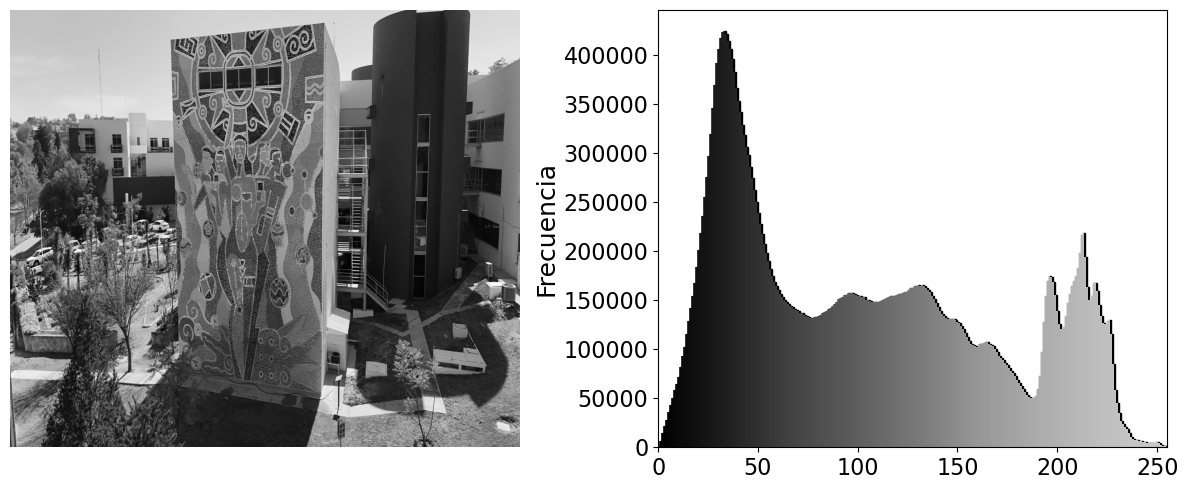

33.56373310089111


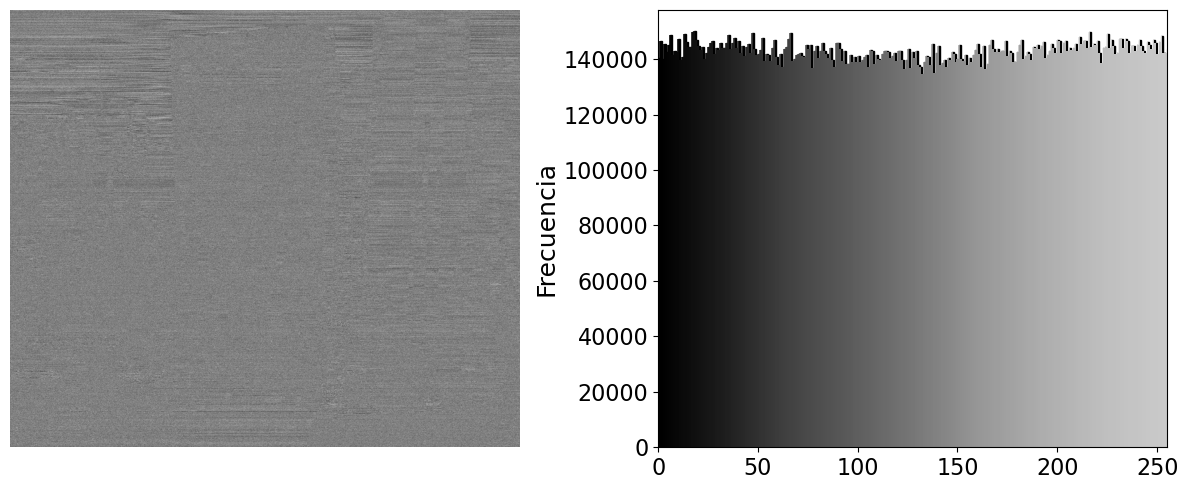

ipimural.JPG
Entropia, Correlacion H, V, D:
0.98747 & 0.98612 & 0.97686 & 7.7297199290543475 \
Cipher Entropia, Correlacion H, V, D:
  0.13239 & 0.00026 & -4e-05 & 7.993874874802562 \
NPCR;UACI;MSE;PSNR


/Users/gaelsegura/Documents/codes/proyectos/research_repos/chaos_cryptography/ciphers.py:274: RuntimeWarning: overflow encountered in scalar subtract
  uaci=(abs(pixel1[x,y]-pixel2[x,y])/255)+uaci


99.61754924449203 & 49.673185954020724 & 10514.289755260386 & 7.9130041963150735 \


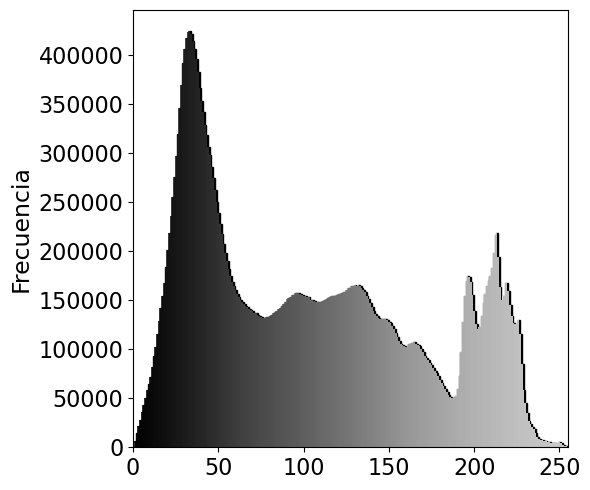

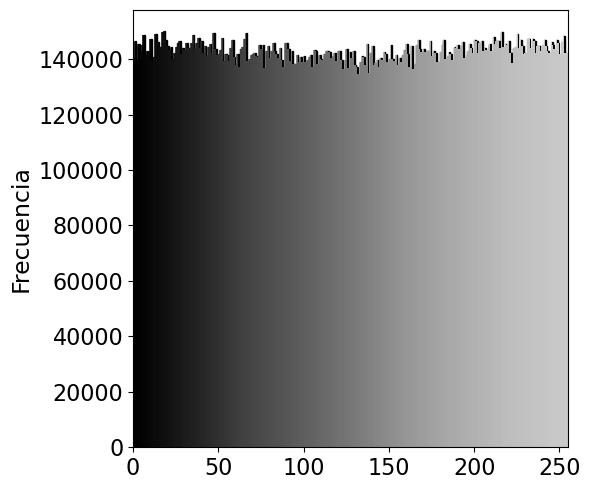

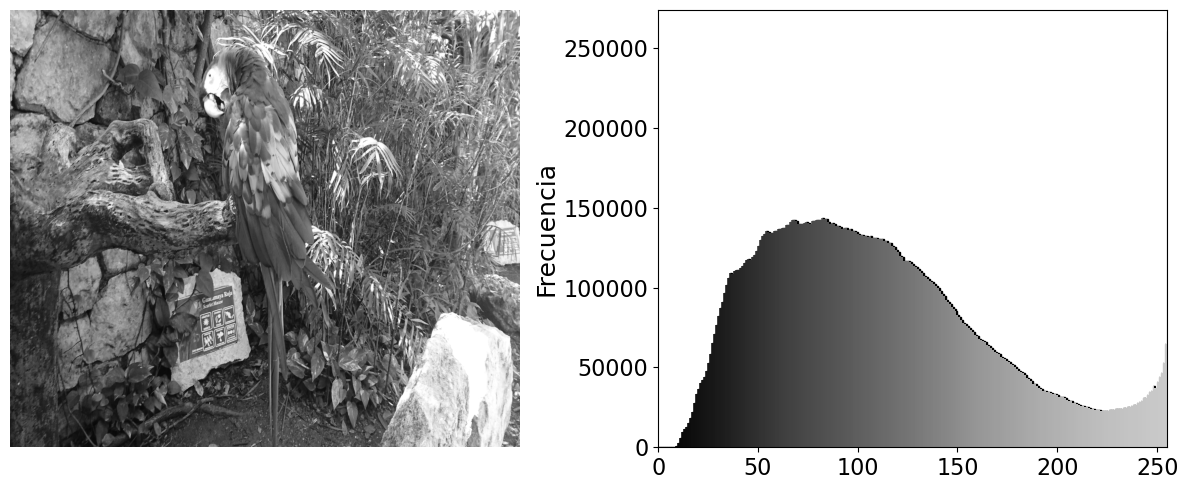

26.330695152282715


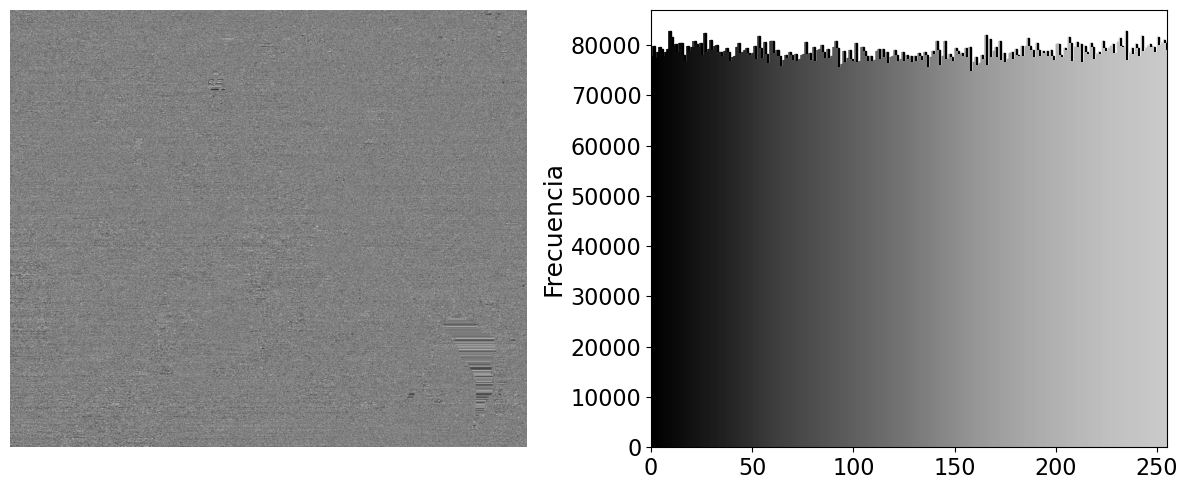

guacamaya.JPG
Entropia, Correlacion H, V, D:
0.98654 & 0.98346 & 0.97527 & 7.635540155281116 \
Cipher Entropia, Correlacion H, V, D:
  0.13709 & 7e-05 & -0.00015 & 7.994022443079562 \
NPCR;UACI;MSE;PSNR


/Users/gaelsegura/Documents/codes/proyectos/research_repos/chaos_cryptography/ciphers.py:274: RuntimeWarning: overflow encountered in scalar subtract
  uaci=(abs(pixel1[x,y]-pixel2[x,y])/255)+uaci


99.62331219556368 & 49.77611209849551 & 9144.73529178423 & 8.519092221851928 \


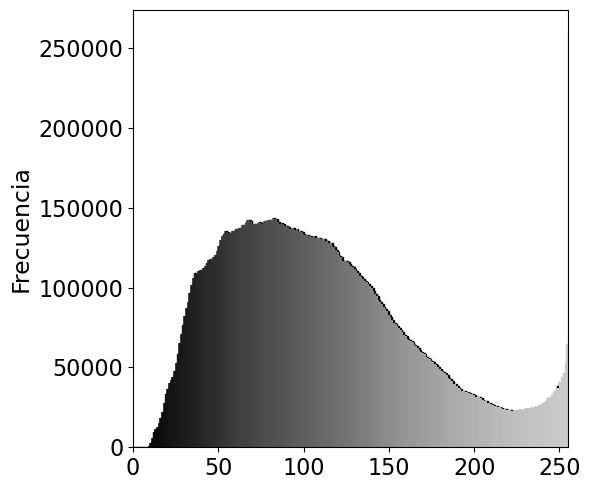

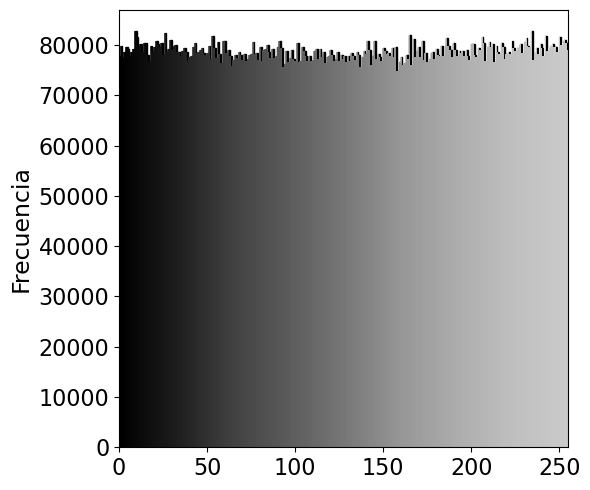

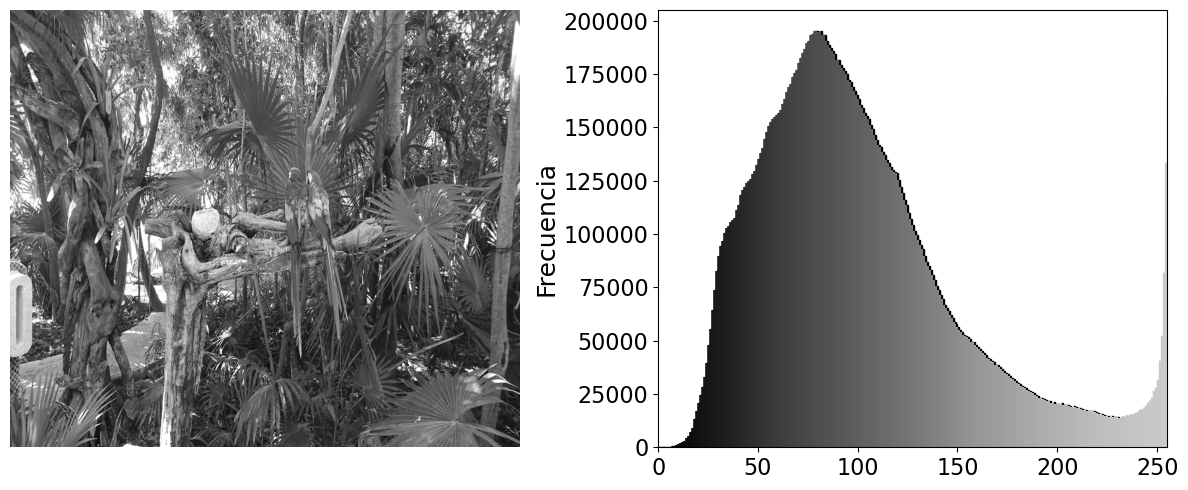

22.935237169265747


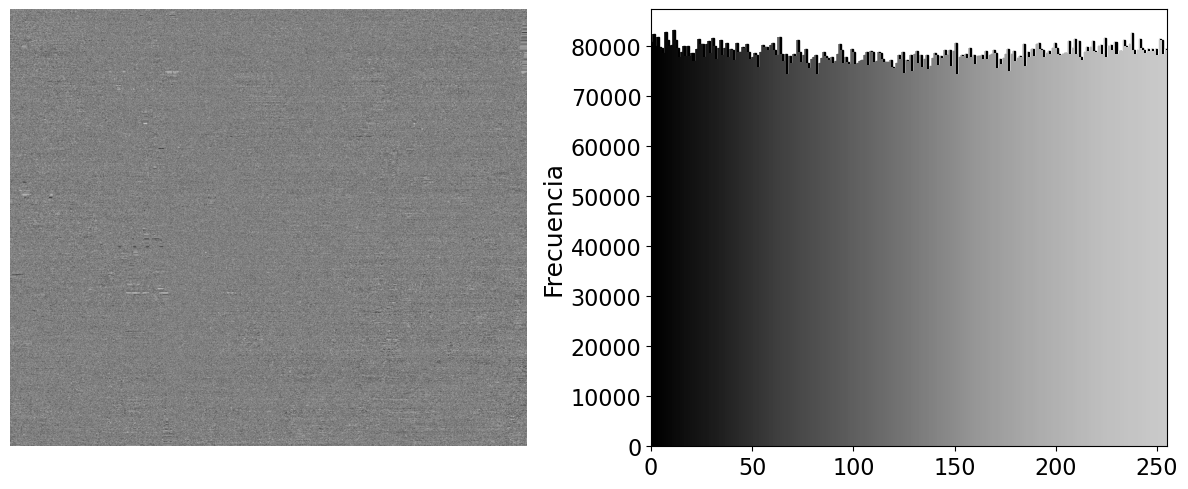

ave.JPG
Entropia, Correlacion H, V, D:
0.95773 & 0.9545 & 0.9228 & 7.469383158115668 \
Cipher Entropia, Correlacion H, V, D:
  0.10702 & 0.00043 & 0.00011 & 7.993847948873655 \
NPCR;UACI;MSE;PSNR


/Users/gaelsegura/Documents/codes/proyectos/research_repos/chaos_cryptography/ciphers.py:274: RuntimeWarning: overflow encountered in scalar subtract
  uaci=(abs(pixel1[x,y]-pixel2[x,y])/255)+uaci


99.62360014902087 & 49.672793599838165 & 8958.910585884005 & 8.608251587174248 \


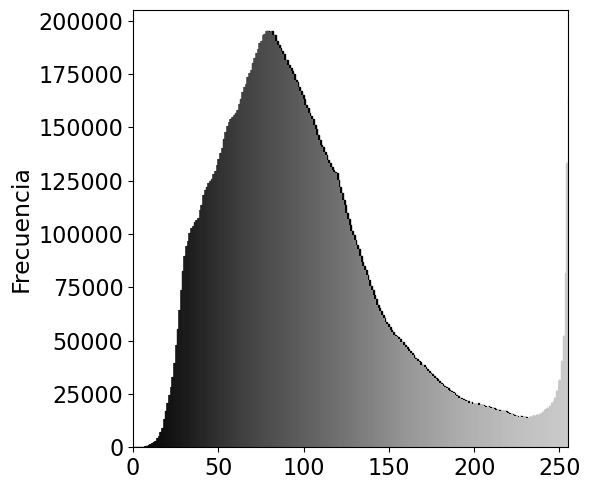

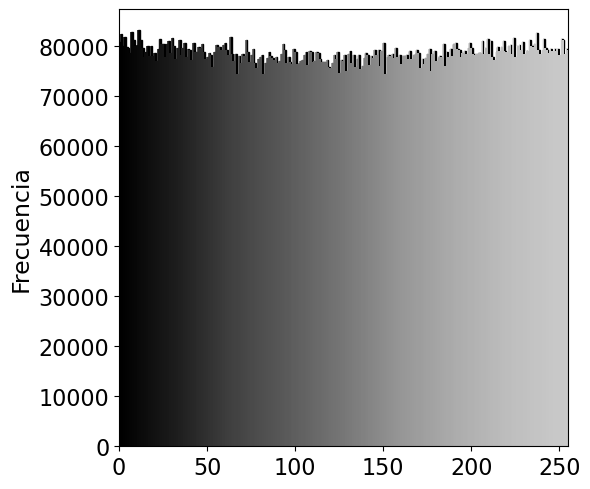

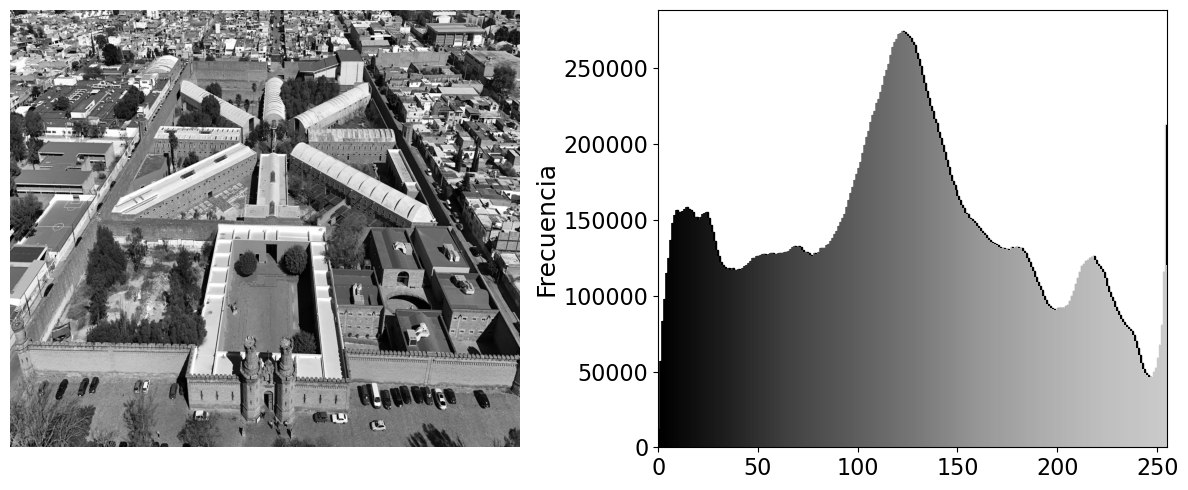

33.94580101966858


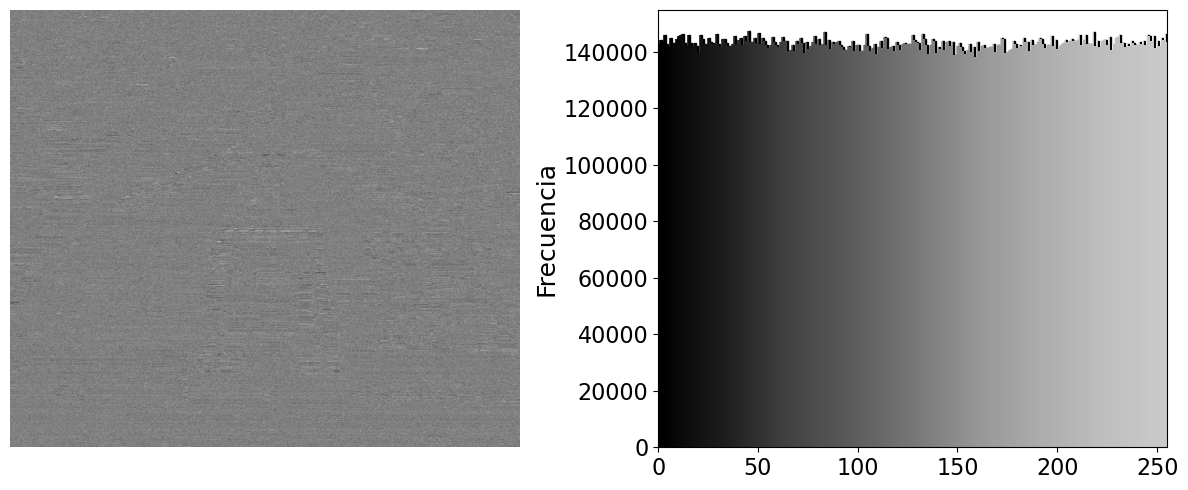

museo.JPG
Entropia, Correlacion H, V, D:
0.98888 & 0.98438 & 0.97632 & 7.904251647397512 \
Cipher Entropia, Correlacion H, V, D:
  0.12164 & 1e-05 & 0.00043 & 7.99415059735715 \
NPCR;UACI;MSE;PSNR


/Users/gaelsegura/Documents/codes/proyectos/research_repos/chaos_cryptography/ciphers.py:274: RuntimeWarning: overflow encountered in scalar subtract
  uaci=(abs(pixel1[x,y]-pixel2[x,y])/255)+uaci


99.61640649057976 & 49.71655729771754 & 9818.4782343107 & 8.210361791558052 \


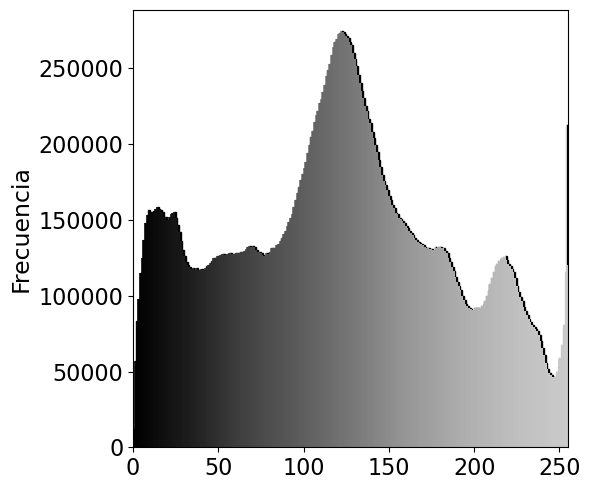

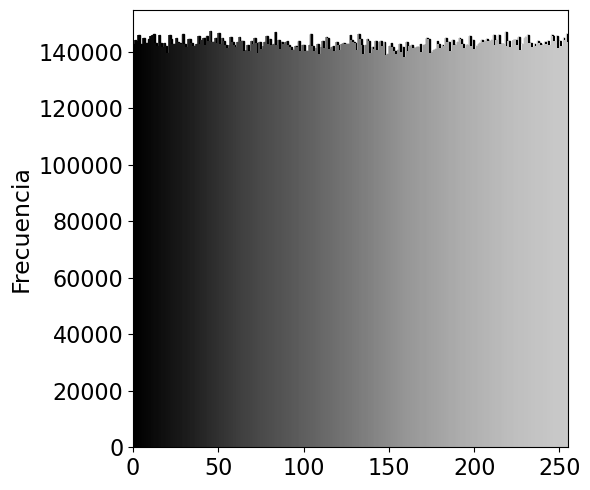

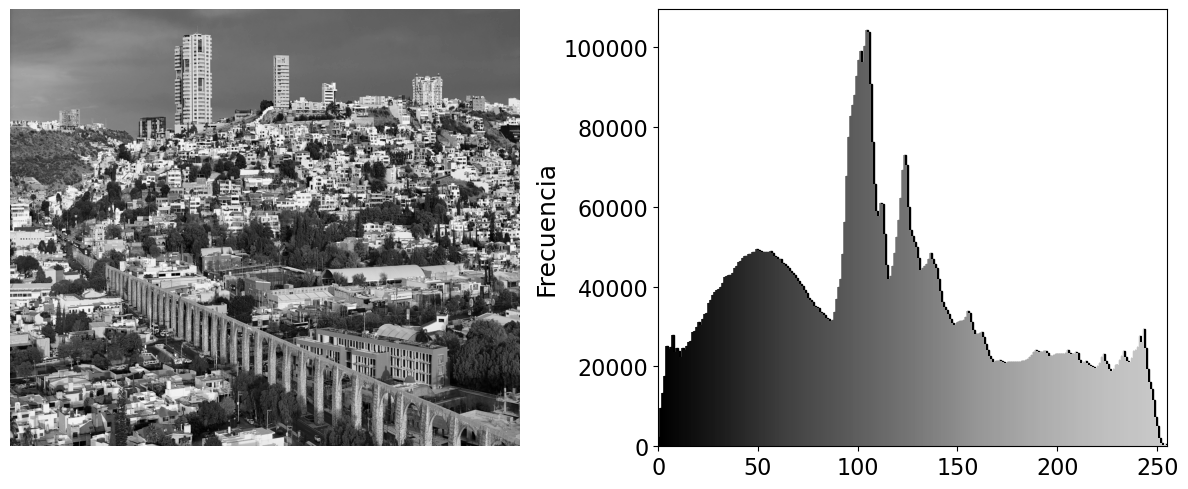

14.67311716079712


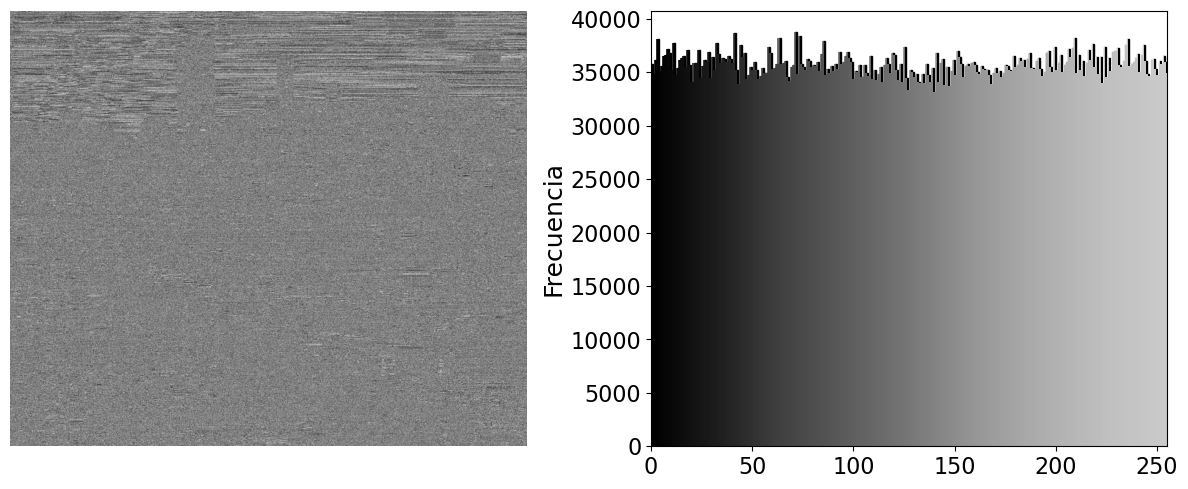

ciudad.JPG
Entropia, Correlacion H, V, D:
0.95524 & 0.95106 & 0.91492 & 7.838572763654832 \
Cipher Entropia, Correlacion H, V, D:
  0.14999 & -0.00024 & -0.00023 & 7.994346856814623 \
NPCR;UACI;MSE;PSNR


/Users/gaelsegura/Documents/codes/proyectos/research_repos/chaos_cryptography/ciphers.py:274: RuntimeWarning: overflow encountered in scalar subtract
  uaci=(abs(pixel1[x,y]-pixel2[x,y])/255)+uaci


99.60708949217548 & 49.71538152302914 & 9570.682671126578 & 8.321374440180161 \
9.389184543064662


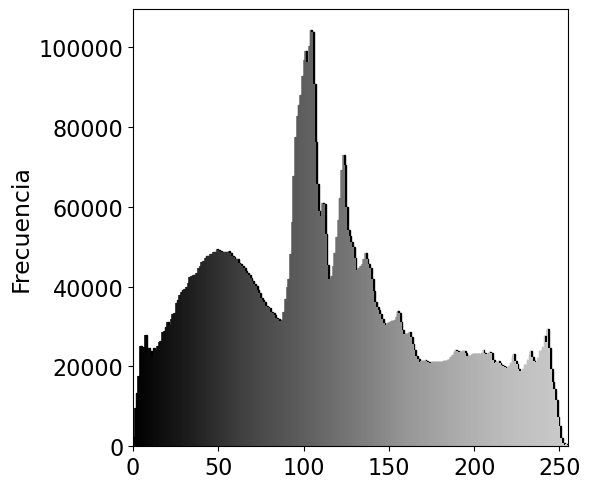

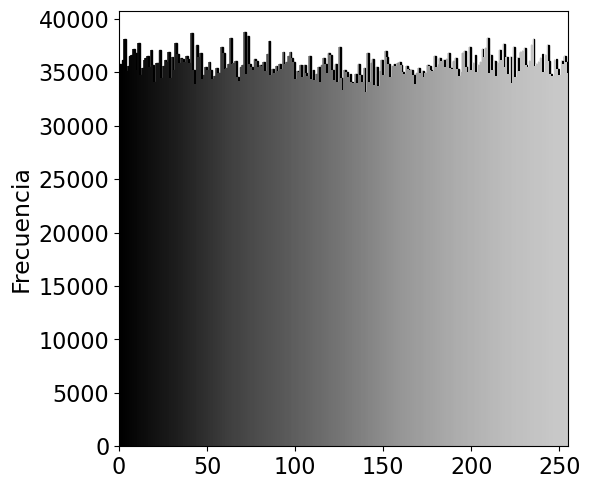

In [15]:
imgs_dir = "/Users/gaelsegura/Documents/codes/proyectos/research_repos/chaos_cryptography/image-dataset/misc"
def bunch_testing(source_dir,exper,tosave=0,tables=0,ciphfunc=ciphers.alberti_cipher):

    # Create the directory              
    if tosave:
        savefolder = source_dir+"_"+exper
        histsavef = source_dir+'/histograms'
        histciphsavef = savefolder+'/histograms'
        try:
            os.mkdir(savefolder)
            print(f"Directory '{savefolder}' created successfully.")
        except FileExistsError:
            print(f"Directory '{savefolder}' already exists.")
        except PermissionError:
            print(f"Permission denied: Unable to create '{savefolder}'.")
            tosave=0
        except Exception as e:
            print(f"An error occurred: {e}")
            tosave=0
        
        try:
            os.mkdir(histsavef)
            print(f"Directory '{histsavef}' created successfully.")
        except FileExistsError:
            print(f"Directory '{histsavef}' already exists.")
        except PermissionError:
            print(f"Permission denied: Unable to create '{histsavef}'.")
            tosave=0
        except Exception as e:
            print(f"An error occurred: {e}")
            tosave=0

        try:
            os.mkdir(histciphsavef)
            print(f"Directory '{histciphsavef}' created successfully.")
        except FileExistsError:
            print(f"Directory '{histciphsavef}' already exists.")
        except PermissionError:
            print(f"Permission denied: Unable to create '{histciphsavef}'.")
            tosave=0
        except Exception as e:
            print(f"An error occurred: {e}")
            tosave=0
        
        # Iterate over files in current directory

    avg=0

    
    for file in glob.glob(source_dir+'/*.JPG'):
        img_filename = os.path.join(source_dir,file)
        imgg = Image.open(img_filename).convert('L')
        hist1,hist2 = ciphers.plot_image_and_histogram(imgg)
        
        startT = time.time()
        imgSBarr = ciphfunc(imgg)
        endT = time.time()
        avg += endT-startT
        print(endT-startT)
        imgEnc = Image.fromarray(imgSBarr).convert('L')
        newhist1,newhist2 = ciphers.plot_image_and_histogram(imgEnc)


        fname = file.split('/')[-1]
        print(fname)

        if tables:
            ogentr = ciphers.calculate_image_entropy(imgg)
            
            entr = ciphers.calculate_image_entropy(imgEnc)
            print("Entropia, Correlacion H, V, D:") 
            corr = ciphers.calculate_pixel_correlation(imgg)
            print(f"{corr['Horizontal']} & {corr['Vertical']} & {corr['Diagonal']} & {ogentr} "+"\\")
            print("Cipher Entropia, Correlacion H, V, D:") 
            corr = ciphers.calculate_pixel_correlation(imgEnc)
            print(f"  {corr['Horizontal']} & {corr['Vertical']} & {corr['Diagonal']} & {entr} "+"\\")
            


            print("NPCR;UACI;MSE;PSNR")
            per_npcr_uaci = ciphers.npcrv_uaci(imgg,imgEnc)
            per_psnr = ciphers.psnr(imgg,imgEnc)
            print(f"{per_npcr_uaci[0]} & {per_npcr_uaci[1]} & {per_psnr[0]} & {per_psnr[1]} "+ "\\")

        if tosave:
            saveroute = savefolder+'/'+exper+fname
            oghistroute = histsavef+'/hist'+fname
            enchistroute = histciphsavef+'/hist'+exper+fname
            # print("hola"+fname)
            # print("hola"+saveroute)
            # print("hola"+oghistroute)
            # print("hola"+enchistroute)
            imgEnc.save(saveroute,format='PNG')
            ciphers.plot_histogram(imgg,tosave=oghistroute)
            ciphers.plot_histogram(imgEnc,tosave=enchistroute)
                    
    print(avg/14)

bunch_testing(imgs_dir,'SBxRow',tables=1,tosave=1)




# Quick tests!

In [5]:
pepper_path = "/Users/gaelsegura/Documents/codes/proyectos/research_repos/chaos_cryptography/image-dataset/512x512/baboon.png"

imggg = Image.open(pepper_path).convert("L")

ciphh = ciphers.alberti_cipher(imggg)
corr = ciphers.calculate_pixel_correlation(imggg)







In [7]:
corr["Horizontal"]

0.8665